## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import geom
from scipy.stats.sampling import DiscreteAliasUrn
from scipy.stats import chisquare
import time
import random
import math
import simpy
import pandas as pd
from collections import Counter

### Exercise 7, Part 1 A
Simulated Annealing

Current route: after shuffle: [ 9 11  0 13  5  8  2  1 14  4  7 10 12  3  6]
Sanity Check Complete.
Initial Bad Cost (Randomized Tour Estimate): 18.5592
Optimized Path Cost: 6.2374


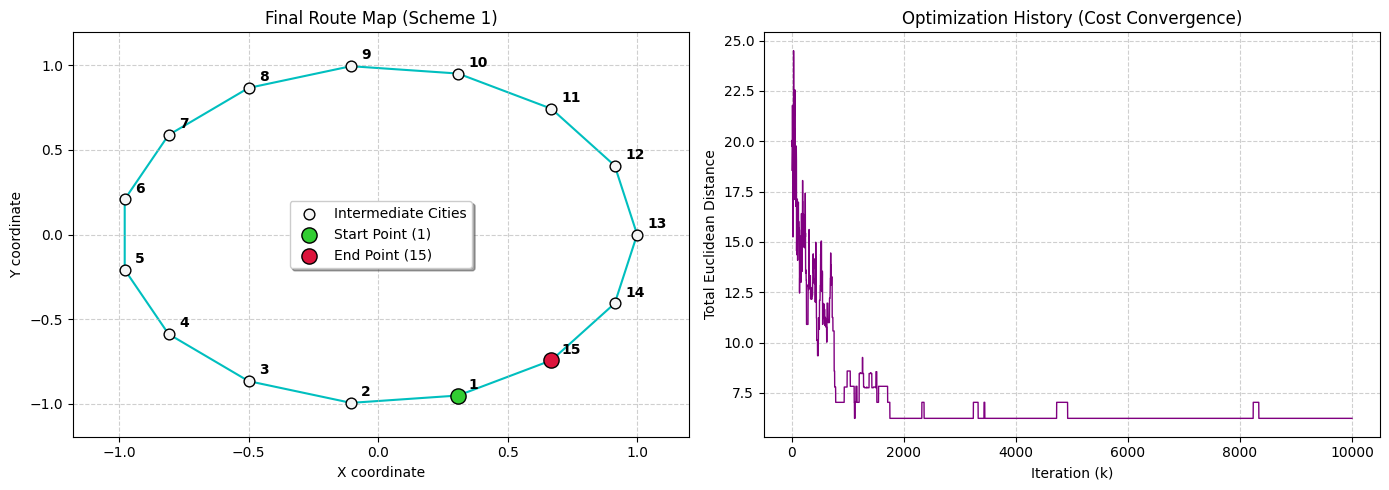

In [ ]:
# set the seed for reproducability
np.random.seed(42)

N = 15
MAX_ITERATIONS = 10_000

# Generate 20 points perfectly on a circle for the sanity check
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
points = np.column_stack((np.cos(angles), np.sin(angles)))

def calculate_total_distance(route, points):
    dist = 0.0
    n = len(route)
    for i in range(n):
        p1 = points[route[i]]
        p2 = points[route[(i + 1) % n]]
        dist += np.linalg.norm(p1 - p2)
    return dist

def propose_new_route(current_route):
    new_route = current_route.copy()
    # Pick two random indices
    idx1, idx2 = sorted(np.random.choice(len(current_route), size=2, replace=False))
    # Reverse the entire segment between them
    new_route[idx1:idx2+1] = new_route[idx1:idx2+1][::-1]
    return new_route

# Helper functions for the Temperature T
def cooling_scheme_1(k):
    return 1.0 / np.sqrt(1 + k)

def cooling_scheme_2(k):
    return 1.0 / np.log(2 + k)

def simulated_annealing_tsp(points, max_iter=MAX_ITERATIONS, scheme='scheme_1'):
    n = len(points)
    
    current_route = np.arange(n)
    # Shuffle the route to test different initial conditions
    np.random.shuffle(current_route) 
    print(f"Current route: after shuffle: {current_route}")
    current_cost = calculate_total_distance(current_route, points)

    best_route = current_route.copy()
    best_cost = current_cost
    
    cost_history = [current_cost]
    
    for k in range(max_iter):
        # Determine temperature based on choice
        if scheme == 'scheme_1':
            T = 10.0 * cooling_scheme_1(k)
        else:
            T = cooling_scheme_2(k)
            
        proposed_route = propose_new_route(current_route)
        proposed_cost = calculate_total_distance(proposed_route, points)
        
        delta_f = proposed_cost - current_cost
        
        if delta_f <= 0:
            current_route = proposed_route
            current_cost = proposed_cost
        else:
            prob = np.exp(-delta_f / T)
            if np.random.rand() < prob:
                # Accept the new route
                current_route = proposed_route
                current_cost = proposed_cost
                
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost
            
        cost_history.append(current_cost)
        
    return best_route, best_cost, cost_history

def plot_tsp_solution(points, route, cost_history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Organize points in the sequence dictated by the route
    ordered_points = points[route]
    # Append the first point to the end to close the visual line loop
    closed_loop_points = np.vstack([ordered_points, ordered_points[0]])
    
    # 1. Plot the path lines connecting the cities
    ax1.plot(closed_loop_points[:, 0], closed_loop_points[:, 1], 'c-', lw=1.5, zorder=1)
    
    # 2. Plot intermediate/middle points (Points 2 through N-1)
    if len(route) > 2:
        ax1.scatter(ordered_points[1:-1, 0], ordered_points[1:-1, 1], 
                    color='whitesmoke', edgecolors='black', s=60, zorder=2, label='Intermediate Cities')
    
    # 3. Highlight First and Last points with unique colors
    start_p = ordered_points[0]
    end_p = ordered_points[-1]
    
    ax1.scatter(start_p[0], start_p[1], color='limegreen', edgecolors='black', s=120, zorder=3, label='Start Point (1)')
    ax1.scatter(end_p[0], end_p[1], color='crimson', edgecolors='black', s=120, zorder=3, label=f'End Point ({len(route)})')
    
    # 4. Add text identifiers (1, 2...N) next to each point with a small visual offset
    for order_idx, point_idx in enumerate(route):
        x, y = points[point_idx]
        ax1.text(x + 0.04, y + 0.04, str(order_idx + 1), fontsize=10, weight='bold', color='black', zorder=4)
    
    ax1.set_title(f"Final Route Map ({title})")
    ax1.set_xlabel("X coordinate")
    ax1.set_ylabel("Y coordinate")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='best', frameon=True, shadow=True)
    
    # Adjust axes limits slightly so labels aren't cut off
    ax1.set_xlim(points[:, 0].min() - 0.2, points[:, 0].max() + 0.2)
    ax1.set_ylim(points[:, 1].min() - 0.2, points[:, 1].max() + 0.2)
    
    # Plot cost convergence
    ax2.plot(cost_history, color='purple', lw=1)
    ax2.set_title("Optimization History (Cost Convergence)")
    ax2.set_xlabel("Iteration (k)")
    ax2.set_ylabel("Total Euclidean Distance")
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# With scheme 1
best_route, best_cost, cost_history = simulated_annealing_tsp(
    points=points, 
    max_iter=MAX_ITERATIONS, 
    scheme='scheme_1'
)

print(f"Sanity Check Complete.")
print(f"Initial Bad Cost (Randomized Tour Estimate): {cost_history[0]:.4f}")
print(f"Optimized Path Cost: {best_cost:.4f}")

plot_tsp_solution(points, best_route, cost_history, title="Scheme 1")

Current route: after shuffle: [ 9  2  1 13 11  8  7 10  0 14 12  5  6  4  3]
Sanity Check Complete.
Initial Bad Cost (Randomized Tour Estimate): 15.6585
Optimized Path Cost: 6.2374


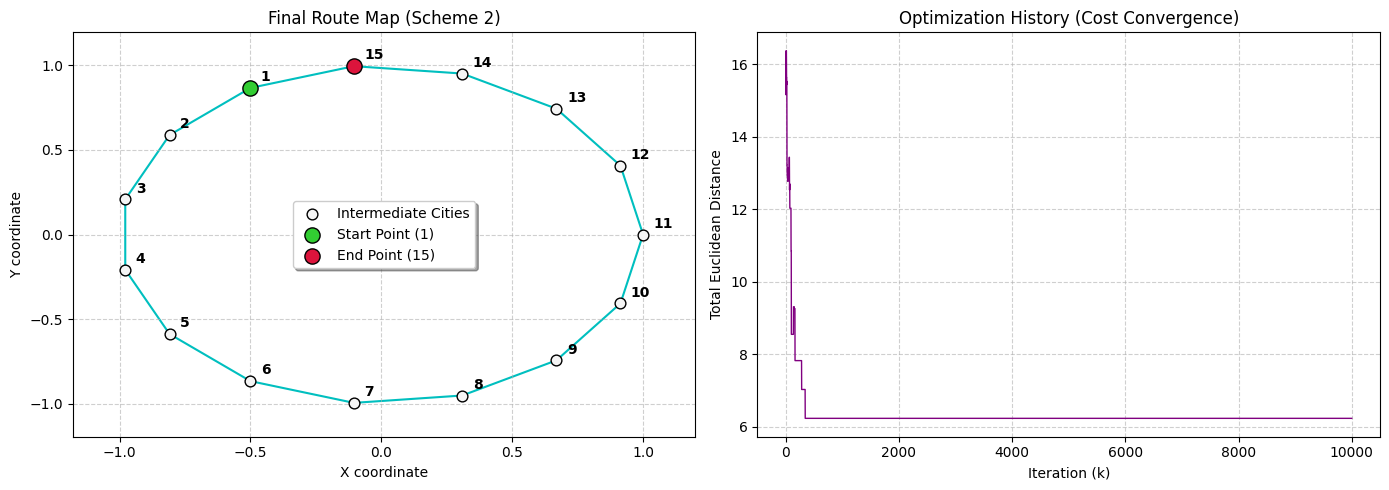

In [45]:
# With scheme 2
best_route, best_cost, cost_history = simulated_annealing_tsp(
    points=points, 
    max_iter=MAX_ITERATIONS, 
    scheme='scheme_2'
)

print(f"Sanity Check Complete.")
print(f"Initial Bad Cost (Randomized Tour Estimate): {cost_history[0]:.4f}")
print(f"Optimized Path Cost: {best_cost:.4f}")

plot_tsp_solution(points, best_route, cost_history, title="Scheme 2")

Exercise 7, Part 2

--- Optimization Complete ---
Initial Random Cost: 3117.00
Optimized Path Cost: 805.00
Optimal Route Order: [11  5 10  2 19  6 17 16  4  7 15  9 18 14  8 13  1 12  0  3]


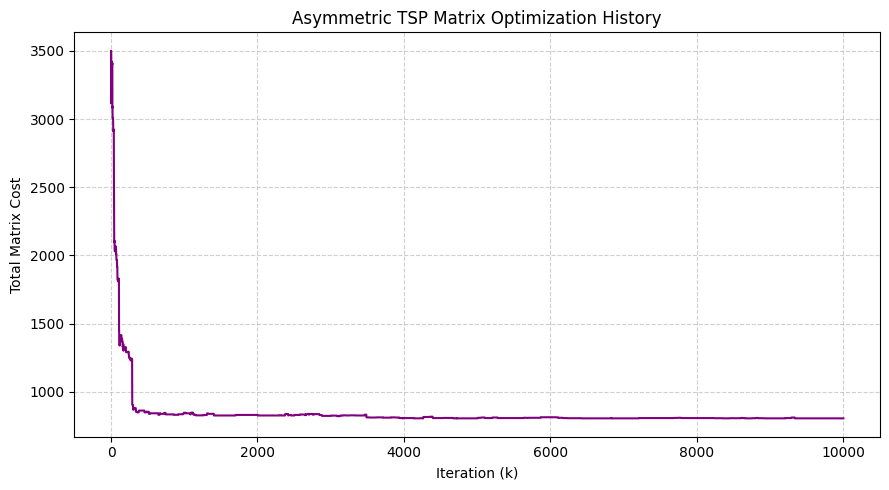

--- Optimization Complete ---
Initial Random Cost: 2371.00
Optimized Path Cost: 854.00
Optimal Route Order: [ 7  4  9 15  1  8 13 14 18 17  6 16 10 19  2  0 12 11  5  3]


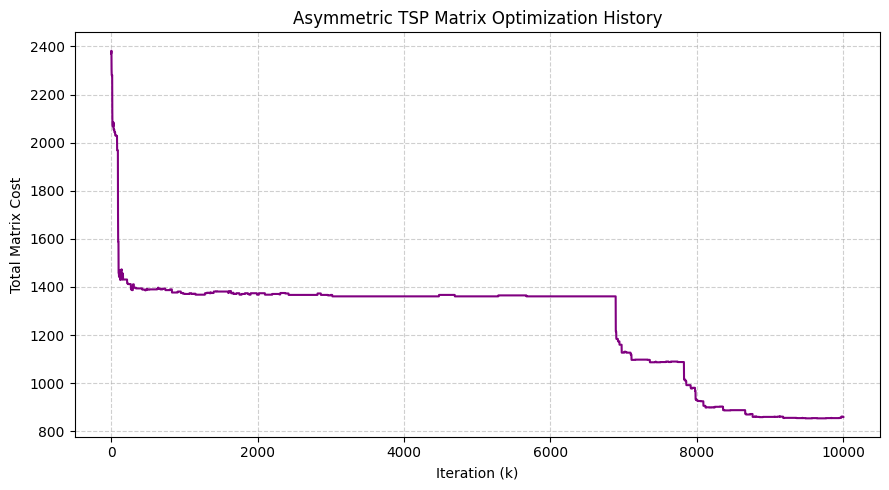

In [64]:
N = cost_matrix.shape[0]
MAX_ITERATIONS = 10_000


def calculate_total_distance(route, cost_matrix):

    dist = 0.0
    n = len(route)
    for i in range(n):
        from_city = route[i]
        to_city = route[(i + 1) % n]
        dist += cost_matrix[from_city, to_city]
    return dist


def propose_new_route(current_route):
    new_route = current_route.copy()
    idx1, idx2 = sorted(np.random.choice(N, size=2, replace=False))
    new_route[idx1:idx2+1] = new_route[idx1:idx2+1][::-1]
    return new_route

def propose_new_route_substring(current_route):
    # Pick the middle segment, and shuffle it
    start = np.random.randint(0, len(current_route) - 2)
    end = np.random.randint(start + 1, len(current_route) - 1)
    new_route = current_route.copy()
    new_route[start:end] = np.random.permutation(new_route[start:end])
    return new_route


def cooling_scheme_1(k):
    return 1.0 / np.sqrt(1 + k)

def simulated_annealing_tsp(cost_matrix, route, max_iter=10000):
    n = len(cost_matrix)
    
    # Generate a randomly scrambled starting route
    current_route = np.arange(n)
    np.random.shuffle(current_route)
    
    current_cost = calculate_total_distance(current_route, cost_matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost
    cost_history = [current_cost]
    
    for k in range(max_iter):
        # Scale factor (150.0) introduced because costs in this matrix 
        # are larger (up to ~300) than our previous unit circle coordinates
        T = 150.0 * cooling_scheme_1(k)

        if route == 'original':
            proposed_route = propose_new_route(current_route)
        else:
            proposed_route = propose_new_route_substring(current_route)

        proposed_cost = calculate_total_distance(proposed_route, cost_matrix)
        
        delta_f = proposed_cost - current_cost
        
        if delta_f <= 0:
            current_route = proposed_route
            current_cost = proposed_cost
        else:
            prob = np.exp(-delta_f / T)
            if np.random.rand() < prob:
                current_route = proposed_route
                current_cost = proposed_cost
                
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost
            
        cost_history.append(current_cost)
        
    return best_route, best_cost, cost_history

best_route, best_cost, cost_history = simulated_annealing_tsp(cost_matrix=pd.read_csv("cost.csv", header=None).to_numpy(), route = 'original', max_iter=MAX_ITERATIONS)

print("--- Optimization Complete ---")
print(f"Initial Random Cost: {cost_history[0]:.2f}")
print(f"Optimized Path Cost: {best_cost:.2f}")

print(f"Optimal Route Order: {best_route}")

# Plotting the Cost History alone
plt.figure(figsize=(9, 5))
plt.plot(cost_history, color='purple', lw=1.5)
plt.title("Asymmetric TSP Matrix Optimization History")
plt.xlabel("Iteration (k)")
plt.ylabel("Total Matrix Cost")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


best_route, best_cost, cost_history = simulated_annealing_tsp(cost_matrix=pd.read_csv("cost.csv", header=None).to_numpy(), route = 'new', max_iter=MAX_ITERATIONS)

print("--- Optimization Complete ---")
print(f"Initial Random Cost: {cost_history[0]:.2f}")
print(f"Optimized Path Cost: {best_cost:.2f}")

print(f"Optimal Route Order: {best_route}")

# Plotting the Cost History alone
plt.figure(figsize=(9, 5))
plt.plot(cost_history, color='purple', lw=1.5)
plt.title("Asymmetric TSP Matrix Optimization History")
plt.xlabel("Iteration (k)")
plt.ylabel("Total Matrix Cost")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Exrcise 8, Part 1

According to the bootstrap, the probability that the sample mean deviates from the true mean by less than 5 units is approximately
Bootstrap estimate of p: 0.7593


<>:38: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\o'
/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_73035/3408611104.py:38: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Bootstrap distribution of $\overline{X}^* - \overline{x}$")


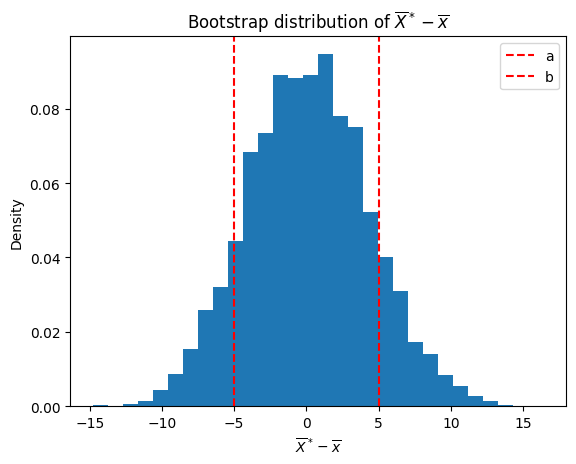

In [102]:
# Bootstrap replaces the unknown distribution by the empirical distribution of the observed data.
x = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69])
n = len(x)

# Given interval
a, b = -5, 5

# Number of bootstrap replications
B = 10000

# Preallocate
bootstrap_statistics = np.zeros(B)

# Sample mean (estimate of μ)
xbar = np.mean(x)

for i in range(B):
    # Resample WITH replacement from the observed data
    sample = np.random.choice(x, size=n, replace=True)

    # Bootstrap sample mean
    xbar_star = np.mean(sample)

    # Centered statistic T* = xbar* - xbar
    bootstrap_statistics[i] = xbar_star - xbar

# Estimate p = P(a < T* < b)
p_hat = np.mean((bootstrap_statistics > a) & (bootstrap_statistics < b))

print("According to the bootstrap, the probability that the sample mean deviates from the true mean by less than 5 units is approximately")
print("Bootstrap estimate of p:", p_hat)

plt.hist(bootstrap_statistics, bins=30, density=True)
plt.axvline(a, color='red', linestyle='--', label='a')
plt.axvline(b, color='red', linestyle='--', label='b')
plt.xlabel("$\\overline{X}^* - \\overline{x}$")
plt.ylabel("Density")
plt.title("Bootstrap distribution of $\overline{X}^* - \overline{x}$")
plt.legend()
plt.show()


Exercise 8, Part 2

n = 15
Data mean = 12.2
Sample variance S^2 = 34.3143
Bootstrap estimate of Var(S^2) ≈ 59.1453


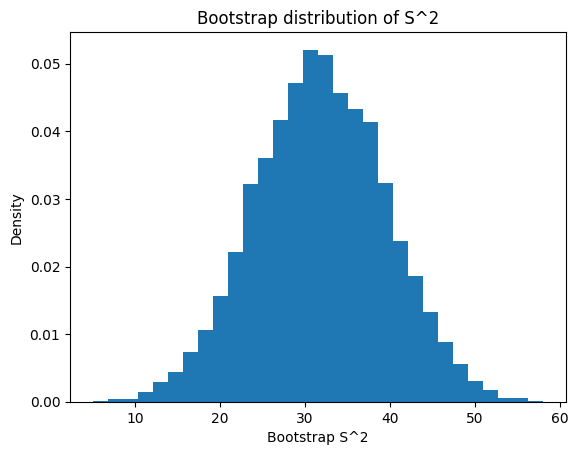

In [ ]:
np.random.seed(42)
x = np.array([5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8])
n = len(x)

print("n =", n)
print("Data mean =", np.mean(x))

S2 = np.var(x, ddof=1)
print("Sample variance S^2 =", round(S2, 4))

# n of bootstrap replications
B = 10_000 
S2_boot = np.zeros(B)

for b in range(B):
    # resampling with replacement
    sample = np.random.choice(x, size=n, replace=True)
    S2_boot[b] = np.var(sample, ddof=1)

# bootstrap estimate of Var(S^2)
Var_S2_boot = np.var(S2_boot, ddof=1)

print("Bootstrap estimate of Var(S^2) ≈", round(Var_S2_boot, 4))

plt.hist(S2_boot, bins=30, density=True)
plt.xlabel("Bootstrap S^2")
plt.ylabel("Density")
plt.title("Bootstrap distribution of S^2")
plt.show()

# using a bootstrap approach, we estimated the variance of the sample variance S^2 to be approximately 58.7.

Exercise 8, Part 3

In [96]:
# Generate a Pareto Sample

np.random.seed(42)

n = 200
beta = 1
k = 1.05
X = beta * (1 + np.random.pareto(k, n))
print(X[0:5])

# Compute a mean and a median
sample_mean = np.mean(X)
sample_median = np.median(X)

print("Sample mean:", round(sample_mean, 4))
print("Sample median:", round(sample_median, 4))

# Estimate the variance of sample mean
B = 1000
mean_boot = np.zeros(B)

for b in range(B):
    sample = np.random.choice(X, size=n, replace=True)
    mean_boot[b] = np.mean(sample)

var_mean_boot = np.var(mean_boot, ddof=1)
print("Bootstrap Var(mean):", round(var_mean_boot, 4))

# Estimate the variance of sample median
median_boot = np.zeros(B)

for b in range(B):
    sample = np.random.choice(X, size=n, replace=True)
    median_boot[b] = np.median(sample)

var_median_boot = np.var(median_boot, ddof=1)
print("Bootstrap Var(median):", round(var_median_boot, 4))

# Compare the precision
print("Ratio Var(mean) / Var(median):", round(var_mean_boot / var_median_boot, 4))


[ 1.56349233 17.58035904  3.50448479  2.38564398  1.17532828]
Sample mean: 4.226
Sample median: 1.915
Bootstrap Var(mean): 0.2523
Bootstrap Var(median): 0.0223
Ratio Var(mean) / Var(median): 11.3332
